In [10]:
import pandas as pd

DATA_PATH = "../data/UCI_dataset/"

X_train = pd.read_csv(DATA_PATH + "train/X_train.txt", sep=r'\s+', header=None).values
X_test  = pd.read_csv(DATA_PATH + "test/X_test.txt",  sep=r'\s+', header=None).values

y_train = pd.read_csv(DATA_PATH + "train/y_train.txt", header=None).values.flatten()
y_test  = pd.read_csv(DATA_PATH + "test/y_test.txt",  header=None).values.flatten()


labels_df = pd.read_csv(DATA_PATH + "activity_labels.txt", sep=' ', header=None)
LABELS = labels_df[1].tolist()

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("Activités:", LABELS)

X_train shape: (7352, 561)
X_test shape: (2947, 561)
Activités: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             f1_score, precision_score, recall_score)

clf_log_reg = LogisticRegression(max_iter=2000, l1_ratio=0)
param_grid = { 'C': [0.01, 0.1, 1, 10],
            'solver': ['saga', 'lbfgs'],
            }

grid_search = GridSearchCV(
    estimator=clf_log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
best = grid_search.best_estimator_
y_pred = best.predict(X_test)


metrics_log_reg = {
        'best_score_cv': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'classification_report': classification_report(y_test, y_pred, digits=4),
    }

print(metrics_log_reg['classification_report'])

Best Hyperparameters: {'C': 1, 'solver': 'lbfgs'}
Best Score: 0.9371673672868195
              precision    recall  f1-score   support

           1     0.9463    0.9940    0.9695       496
           2     0.9695    0.9448    0.9570       471
           3     0.9902    0.9667    0.9783       420
           4     0.9751    0.8778    0.9239       491
           5     0.9014    0.9793    0.9387       532
           6     1.0000    1.0000    1.0000       537

    accuracy                         0.9613      2947
   macro avg     0.9637    0.9604    0.9612      2947
weighted avg     0.9627    0.9613    0.9612      2947



In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

clf_RF = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = RandomizedSearchCV(
    estimator=clf_RF,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
best = grid_search.best_estimator_
y_pred = best.predict(X_test)


metrics_rf = {
        'best_score_cv': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'classification_report': classification_report(y_test, y_pred, digits=4),
    }


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best Score: 0.9311802328001221


In [34]:
print(metrics_rf['classification_report'])

              precision    recall  f1-score   support

           1     0.9108    0.9677    0.9384       496
           2     0.8925    0.9342    0.9129       471
           3     0.9591    0.8381    0.8945       420
           4     0.9688    0.8859    0.9255       491
           5     0.9024    0.9737    0.9367       532
           6     1.0000    1.0000    1.0000       537

    accuracy                         0.9372      2947
   macro avg     0.9389    0.9333    0.9347      2947
weighted avg     0.9392    0.9372    0.9368      2947



In [27]:
from sklearn.svm import SVC

clf_svc = SVC()

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    estimator=clf_svc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
best = grid_search.best_estimator_
y_pred = best.predict(X_test)


metrics_svc = {
        'best_score_cv': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'classification_report': classification_report(y_test, y_pred, digits=4),
    }


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 4/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.948 total time=   3.4s
[CV 1/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.929 total time=   3.5s
[CV 5/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.964 total time=   5.4s
[CV 2/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.895 total time=   5.7s
[CV 3/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.956 total time=   6.1s
[CV 1/5] END ..C=0.1, gamma=auto, kernel=linear;, score=0.929 total time=   5.0s
[CV 2/5] END ..C=0.1, gamma=auto, kernel=linear;, score=0.895 total time=   4.7s
[CV 4/5] END ..C=0.1, gamma=auto, kernel=linear;, score=0.948 total time=   4.7s
[CV 3/5] END ..C=0.1, gamma=auto, kernel=linear;, score=0.956 total time=   5.3s
[CV 5/5] END ..C=0.1, gamma=auto, kernel=linear;, score=0.964 total time=   3.8s
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.889 total time=  23.6s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf

In [29]:
print(metrics_svc['classification_report'])

              precision    recall  f1-score   support

           1     0.9587    0.9839    0.9711       496
           2     0.9418    0.9618    0.9517       471
           3     0.9900    0.9405    0.9646       420
           4     0.9778    0.8961    0.9352       491
           5     0.9142    0.9812    0.9465       532
           6     1.0000    1.0000    1.0000       537

    accuracy                         0.9620      2947
   macro avg     0.9637    0.9606    0.9615      2947
weighted avg     0.9631    0.9620    0.9619      2947



In [30]:
from sklearn.neighbors import KNeighborsClassifier

clf_knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 19, 23],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}


grid_search = GridSearchCV(
    estimator=clf_knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
best = grid_search.best_estimator_
y_pred = best.predict(X_test)


metrics_knn = {
        'best_score_cv': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'classification_report': classification_report(y_test, y_pred, digits=4),
    }



Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best Score: 0.9080556056549065


In [31]:
print(metrics_knn['classification_report'])

              precision    recall  f1-score   support

           1     0.8645    0.9778    0.9177       496
           2     0.8848    0.9130    0.8986       471
           3     0.9737    0.7929    0.8740       420
           4     0.9738    0.8330    0.8979       491
           5     0.8669    0.9793    0.9197       532
           6     1.0000    1.0000    1.0000       537

    accuracy                         0.9213      2947
   macro avg     0.9273    0.9160    0.9180      2947
weighted avg     0.9266    0.9213    0.9205      2947



In [38]:
from xgboost import XGBClassifier

clf_boost = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_child_weight': [1, 5]
}


grid_search = RandomizedSearchCV(
    estimator=clf_boost,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

y_train = y_train - 1
y_test  = y_test - 1

grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
best = grid_search.best_estimator_
y_pred = best.predict(X_test)


metrics_boost = {
        'best_score_cv': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'classification_report': classification_report(y_test, y_pred, digits=4),
    }

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:24:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:24:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:24:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:24:35] WARNING: /__w/xgboost/xgboost/

Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best Score: 0.9246482331885849


In [40]:
print(metrics_boost['classification_report'])

              precision    recall  f1-score   support

           0     0.9346    0.9798    0.9567       496
           1     0.9226    0.9363    0.9294       471
           2     0.9719    0.9071    0.9384       420
           3     0.9378    0.8595    0.8969       491
           4     0.8842    0.9474    0.9147       532
           5     1.0000    1.0000    1.0000       537

    accuracy                         0.9403      2947
   macro avg     0.9419    0.9384    0.9394      2947
weighted avg     0.9414    0.9403    0.9401      2947



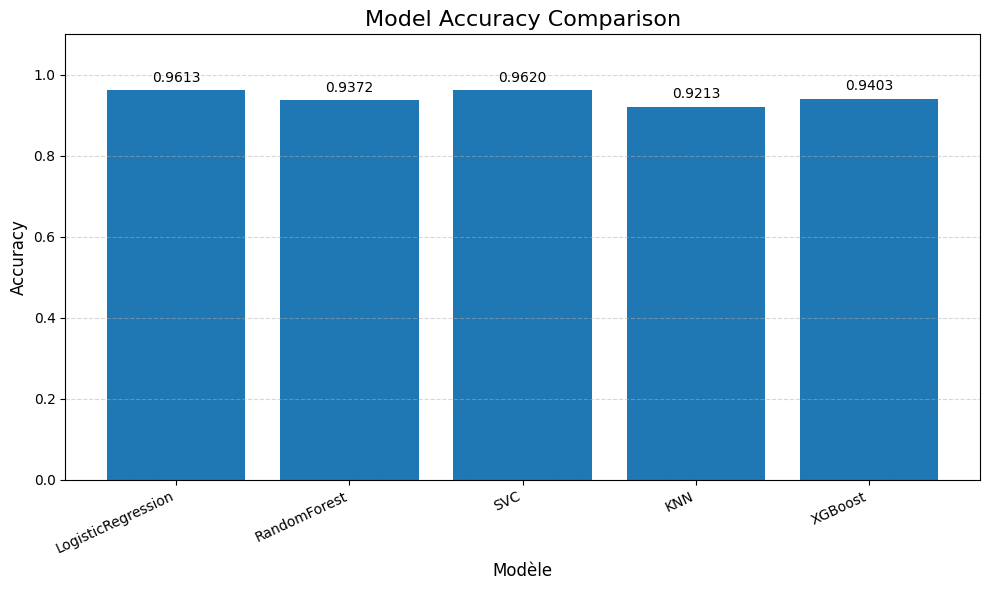

In [55]:
import matplotlib.pyplot as plt

accuracy_by_model = {
    'LogisticRegression': metrics_log_reg['accuracy'],
    'RandomForest': metrics_rf['accuracy'],
    'SVC': metrics_svc['accuracy'],
    'KNN': metrics_knn['accuracy'],
    'XGBoost': metrics_boost['accuracy'],
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(accuracy_by_model.keys(), accuracy_by_model.values(), color='tab:blue')
ax.set_ylim(0, 1.1)
ax.set_title('Model Accuracy Comparison', fontsize=16)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Modèle', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig("accuracy_model_ML")
plt.show()
